<a href="https://colab.research.google.com/github/ReposofPriyanka/flyrank-ai-internship-ml-track/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper


## 1. Question

### Research Question

Can observed search-performance signals be used to identify ranking and content opportunities, while content archetypes provide additional context for prioritizing pages for human review?

### Selected Approach

This capstone combines two analytical approaches:

1. **Ranking Signal Analysis** — supervised machine learning is used to model observed search-performance outcomes and identify which available signals contribute most to predictions.
2. **Structured Content Archetype Clustering** — unsupervised learning is used to group content items with similar measurable characteristics and examine whether different archetypes show different performance patterns.

These analyses feed a **content opportunity prioritization system** that ranks pages for human review.

### Decision Supported

The system is designed to help an SEO or content team decide **which pages deserve review first**, what evidence supports that priority, and what type of content pattern may provide useful context.

The output is a ranked review queue containing an opportunity score, supporting signals, archetype information where available, and suggested review actions.

### Scope

This project analyzes observed data patterns. It does not attempt to reproduce Google's ranking algorithm, prove that a particular signal causes ranking changes, or guarantee that a content change will improve future search performance.


## 2. Data



In [1]:
# CAPSTONE — Day 1: Data availability audit

# We first inspect the warehouse schema before deciding which
# ranking, content, freshness, or authority features can be used.

!pip -q install duckdb pandas pyarrow

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

# --------------------------------------------------
# 1. Connect to FlyRank warehouse
# --------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN is missing. Add your Hugging Face READ token "
        "in Colab Secrets and enable notebook access."
    )

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

# --------------------------------------------------
# 2. Inspect available columns
# --------------------------------------------------

schema_query = f"""
DESCRIBE
SELECT *
FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
"""

schema_df = con.sql(schema_query).df()

print("Available warehouse fields:")
display(schema_df)

Available warehouse fields:


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [2]:
# --------------------------------------------------
# 3. Inspect one sample row
# --------------------------------------------------

sample_query = f"""
SELECT *
FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
LIMIT 3
"""

sample_df = con.sql(sample_query).df()

print("Sample rows:")
display(sample_df)

Sample rows:


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01


In [3]:
# CAPSTONE — Day 1: Temporal coverage audit

coverage_query = f"""
SELECT
    month,
    COUNT(*) AS daily_rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items,

    SUM(
        CASE
            WHEN gsc_data_available IS TRUE THEN 1
            ELSE 0
        END
    ) AS gsc_available_rows,

    SUM(
        CASE
            WHEN ga4_data_available IS TRUE THEN 1
            ELSE 0
        END
    ) AS ga4_available_rows

FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)

GROUP BY month
ORDER BY month
"""

coverage_df = con.sql(coverage_query).df()

print("Monthly warehouse coverage:")
display(coverage_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly warehouse coverage:


,month,daily_rows,clients,content_items,gsc_available_rows,ga4_available_rows
0,2025-01,1297,2,476,1297.0,0.0
1,2025-02,75985,3,5903,75985.0,0.0
2,2025-03,167859,4,10374,167859.0,0.0
3,2025-04,285114,4,13046,285114.0,0.0
4,2025-05,349923,4,14887,349923.0,0.0
5,2025-06,329201,9,16399,329201.0,0.0
6,2025-07,469794,16,27945,469794.0,0.0
7,2025-08,704962,15,37204,704962.0,0.0
8,2025-09,845813,23,53127,845813.0,0.0
9,2025-10,2165471,31,110339,1187654.0,9545.0


In [4]:
# CAPSTONE — Day 1: Confirm final warehouse date

final_coverage_query = f"""
SELECT
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date,
    MIN(month) AS first_month,
    MAX(month) AS last_month,
    COUNT(DISTINCT month) AS number_of_months
FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
"""

final_coverage_df = con.sql(final_coverage_query).df()

display(final_coverage_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_date,last_date,first_month,last_month,number_of_months
0,2025-01-27,2026-06-30,2025-01,2026-06,18


In [5]:
# CAPSTONE — Day 1: Build temporal modeling dataset

import pandas as pd
import numpy as np

temporal_query = f"""
WITH monthly AS (

    SELECT
        client_hash_id,
        content_hash_id,
        month,

        -- GSC search signals
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_sum_position) AS sum_position,

        -- GA4 engagement signals
        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_users) AS users,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_seconds,

        -- Traffic sources
        SUM(sessions_organic) AS sessions_organic,
        SUM(sessions_direct) AS sessions_direct,
        SUM(sessions_referral) AS sessions_referral,
        SUM(sessions_social) AS sessions_social,
        SUM(sessions_paid) AS sessions_paid,
        SUM(sessions_ai) AS sessions_ai,

        -- Engagement
        SUM(scroll_events) AS scroll_events,

        -- Availability flags
        BOOL_OR(gsc_data_available) AS has_gsc,
        BOOL_OR(ga4_data_available) AS has_ga4

    FROM read_parquet(
        '{REL}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )

    GROUP BY
        client_hash_id,
        content_hash_id,
        month
),

features AS (

    SELECT
        *,

        -- Monthly CTR
        CASE
            WHEN impressions > 0
            THEN clicks * 1.0 / impressions
            ELSE NULL
        END AS ctr,

        -- Weighted average position
        CASE
            WHEN impressions > 0
            THEN sum_position * 1.0 / impressions
            ELSE NULL
        END AS avg_position

    FROM monthly
),

paired AS (

    SELECT
        current.*,

        next_month.impressions AS next_impressions,
        next_month.clicks AS next_clicks,
        next_month.avg_position AS next_avg_position

    FROM features AS current

    LEFT JOIN features AS next_month

        ON current.client_hash_id = next_month.client_hash_id
        AND current.content_hash_id = next_month.content_hash_id

        AND CAST(
            strptime(current.month, '%Y-%m') + INTERVAL '1 month'
            AS DATE
        )
        =
        CAST(
            strptime(next_month.month, '%Y-%m')
            AS DATE
        )
)

SELECT
    *,

    -- Future impression trend
    CASE
        WHEN impressions > 0
             AND next_impressions IS NOT NULL
        THEN
            (next_impressions - impressions) * 1.0
            / impressions
        ELSE NULL
    END AS future_trend_pct

FROM paired

WHERE
    has_gsc = TRUE
    AND impressions > 0
"""

model_df = con.sql(temporal_query).df()

print("Temporal modeling dataset:")
print(f"Rows: {len(model_df):,}")
print(f"Columns: {len(model_df.columns)}")
display(model_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Temporal modeling dataset:
Rows: 1,546,456
Columns: 26


,client_hash_id,content_hash_id,month,impressions,clicks,sum_position,pageviews,sessions,users,engaged_sessions,...,sessions_ai,scroll_events,has_gsc,has_ga4,ctr,avg_position,next_impressions,next_clicks,next_avg_position,future_trend_pct
0,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,2025-01,115.0,1.0,606.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.008696,5.269565,734.0,7.0,12.062670,5.382609
1,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,2025-01,22.0,0.0,642.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.000000,29.181818,136.0,1.0,32.477941,5.181818
2,client_9958f0a7ae1df715,content_e281674658070602,2025-01,25.0,0.0,866.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.000000,34.640000,61.0,1.0,13.721311,1.440000
3,client_9958f0a7ae1df715,content_da9cd3207814ec8d,2025-01,136.0,0.0,893.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.000000,6.566176,709.0,3.0,11.730606,4.213235
4,client_9958f0a7ae1df715,content_96fe7476fada560c,2025-01,139.0,1.0,5147.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.007194,37.028777,748.0,10.0,27.878342,4.381295


In [6]:
# CAPSTONE — Day 1: Leakage and target audit

# --------------------------------------------------
# 1. Target coverage
# --------------------------------------------------

print("TARGET COVERAGE")
print("-" * 40)

target_total = len(model_df)
target_available = model_df["future_trend_pct"].notna().sum()
target_missing = model_df["future_trend_pct"].isna().sum()

print(f"Total rows:        {target_total:,}")
print(f"Target available:  {target_available:,}")
print(f"Target missing:    {target_missing:,}")

# --------------------------------------------------
# 2. Check for impossible / invalid values
# --------------------------------------------------

print("\nINVALID VALUE CHECK")
print("-" * 40)

numeric_cols = [
    "impressions",
    "clicks",
    "sum_position",
    "ctr",
    "avg_position",
    "next_impressions",
    "next_clicks",
    "next_avg_position",
    "future_trend_pct"
]

for col in numeric_cols:
    if col in model_df.columns:
        invalid = np.isinf(model_df[col].fillna(0)).sum()
        print(f"{col:22s}: {invalid:,} infinite values")

# --------------------------------------------------
# 3. Check feature / target relationships
# --------------------------------------------------

print("\nTARGET SUMMARY")
print("-" * 40)

display(
    model_df["future_trend_pct"]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .to_frame()
)

# --------------------------------------------------
# 4. Explicit leakage check
# --------------------------------------------------

feature_candidates = [
    "impressions",
    "clicks",
    "sum_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_seconds",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events",
    "ctr",
    "avg_position"
]

leakage_columns = [
    "next_impressions",
    "next_clicks",
    "next_avg_position",
    "future_trend_pct"
]

print("\nFEATURE / LEAKAGE AUDIT")
print("-" * 40)

print("Candidate model features:")
print(feature_candidates)

print("\nColumns explicitly excluded from model features:")
print(leakage_columns)

TARGET COVERAGE
----------------------------------------
Total rows:        1,546,456
Target available:  1,316,498
Target missing:    229,958

INVALID VALUE CHECK
----------------------------------------
impressions           : 0 infinite values
clicks                : 0 infinite values
sum_position          : 0 infinite values
ctr                   : 0 infinite values
avg_position          : 0 infinite values
next_impressions      : 0 infinite values
next_clicks           : 0 infinite values
next_avg_position     : 0 infinite values
future_trend_pct      : 0 infinite values

TARGET SUMMARY
----------------------------------------


,future_trend_pct
count,1.316498e+06
mean,2.093078e+00
std,4.683583e+01
min,-1.000000e+00
1%,-1.000000e+00
5%,-1.000000e+00
25%,-5.929176e-01
50%,-7.505178e-02
75%,6.628766e-01
95%,5.355336e+00



FEATURE / LEAKAGE AUDIT
----------------------------------------
Candidate model features:
['impressions', 'clicks', 'sum_position', 'pageviews', 'sessions', 'users', 'engaged_sessions', 'engagement_seconds', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events', 'ctr', 'avg_position']

Columns explicitly excluded from model features:
['next_impressions', 'next_clicks', 'next_avg_position', 'future_trend_pct']


In [7]:
# CAPSTONE — Day 1: Target coverage and stability by month

monthly_target_audit = (
    model_df
    .groupby("month")
    .agg(
        rows=("content_hash_id", "size"),
        target_available=("future_trend_pct", "count"),
        median_impressions=("impressions", "median"),
        median_future_trend=("future_trend_pct", "median"),
        p95_future_trend=(
            "future_trend_pct",
            lambda x: x.quantile(0.95)
        )
    )
    .reset_index()
)

monthly_target_audit["target_coverage_pct"] = (
    monthly_target_audit["target_available"]
    / monthly_target_audit["rows"]
    * 100
)

display(monthly_target_audit)

,month,rows,target_available,median_impressions,median_future_trend,p95_future_trend,target_coverage_pct
0,2025-01,476,327,5.0,2.727273,20.948214,68.697479
1,2025-02,5903,4885,93.0,1.053356,6.439588,82.754532
2,2025-03,10374,10060,84.0,1.063942,23.142857,96.973202
3,2025-04,13046,12616,182.0,0.413969,5.643908,96.703971
4,2025-05,14887,13948,227.0,-0.083333,1.613843,93.692483
5,2025-06,16399,14939,169.0,0.000000,4.800000,91.097018
6,2025-07,27945,25884,95.0,0.252279,14.312143,92.624799
7,2025-08,37204,33891,108.0,-0.135447,6.500000,91.095044
8,2025-09,53127,50552,76.0,0.301755,10.333333,95.153124
9,2025-10,64906,64552,66.0,0.250000,7.576786,99.454596


## 3. Methodology

### 3.1 Modeling Objective

The supervised learning task is to estimate next-month search demand for a content item using only information available during the current month.

The model uses current-period search-performance and engagement signals and predicts:

**next-month Google Search impressions**

This temporal framing avoids using future observations as model inputs and better reflects the intended decision setting: identifying pages whose current signals indicate meaningful future search-performance opportunity.

### 3.2 Feature Construction

For each `client_hash_id` and `content_hash_id`, daily warehouse records are aggregated to the monthly level.

The candidate feature set includes:

- GSC impressions
- GSC clicks
- derived click-through rate (CTR)
- weighted average search position
- GA4 pageviews
- GA4 sessions
- GA4 users
- GA4 engaged sessions
- total engagement time
- organic sessions
- direct sessions
- referral sessions
- social sessions
- paid sessions
- AI sessions
- scroll events

Client and content identifiers are retained for grouping and analysis but are not used as predictive features.

GA4-derived features are interpreted only where GA4 data is available.

### 3.3 Temporal Design

The dataset is organized as a sequence of month-to-month observations:

**Month T features → Month T+1 search outcome**

The final month in the warehouse is excluded from supervised modeling because no subsequent month is available for target construction.

The data is split chronologically rather than randomly so that future observations cannot enter model training.

### 3.4 Model Comparison

A simple baseline will be compared with tree-based machine-learning models.

The baseline represents a simple prediction strategy using the training-set target distribution.

The candidate machine-learning models are:

1. Random Forest Regressor
2. Gradient-boosted tree model

Model performance will be evaluated on the same held-out temporal test period.

Primary evaluation metrics will include:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

Model interpretation will use feature importance and, where appropriate, SHAP-based explanations.

### 3.5 Opportunity Scoring

Model predictions are not treated as proof of causal SEO effects.

Instead, model outputs are combined with observable search-performance signals to create a prioritization score for human review.

The opportunity layer considers factors such as:

- current search visibility
- current CTR
- current ranking position
- predicted future search demand
- observed impression trend
- data quality and availability

The resulting score is used to rank content items for review rather than to guarantee that an optimization will improve search performance.

### 3.6 Content Archetype Analysis

A separate unsupervised analysis will group content items according to measurable search-performance and engagement characteristics.

Because the warehouse does not provide direct semantic fields such as page text, title, content length, or explicit content type, these clusters will be described as **performance archetypes**, not semantic content categories.

The archetypes will provide additional context for interpreting opportunity groups and prioritizing human review.

## 4. Results (vs baseline)


In [8]:
# CAPSTONE — Step 6: Temporal Train / Validation / Test Split

# Keep only observations with a known next-month outcome.
model_ready_df = model_df[
    model_df["future_trend_pct"].notna()
].copy()

# --------------------------------------------------
# 1. Define chronological periods
# --------------------------------------------------

train_months = [
    "2025-01", "2025-02", "2025-03", "2025-04",
    "2025-05", "2025-06", "2025-07", "2025-08",
    "2025-09", "2025-10", "2025-11", "2025-12"
]

validation_months = [
    "2026-01", "2026-02", "2026-03"
]

test_months = [
    "2026-04", "2026-05"
]

# --------------------------------------------------
# 2. Create splits
# --------------------------------------------------

train_df = model_ready_df[
    model_ready_df["month"].isin(train_months)
].copy()

validation_df = model_ready_df[
    model_ready_df["month"].isin(validation_months)
].copy()

test_df = model_ready_df[
    model_ready_df["month"].isin(test_months)
].copy()

# --------------------------------------------------
# 3. Display split sizes
# --------------------------------------------------

print("TEMPORAL DATA SPLIT")
print("=" * 50)

print(f"Train:      {len(train_df):,} rows")
print(f"Validation: {len(validation_df):,} rows")
print(f"Test:       {len(test_df):,} rows")

print("\nTrain period:")
print(f"{train_df['month'].min()} → {train_df['month'].max()}")

print("\nValidation period:")
print(f"{validation_df['month'].min()} → {validation_df['month'].max()}")

print("\nTest period:")
print(f"{test_df['month'].min()} → {test_df['month'].max()}")

TEMPORAL DATA SPLIT
Train:      440,304 rows
Validation: 443,560 rows
Test:       432,634 rows

Train period:
2025-01 → 2025-12

Validation period:
2026-01 → 2026-03

Test period:
2026-04 → 2026-05


In [9]:
# Verify that the temporal split contains no overlapping months

print("\nMONTH OVERLAP CHECK")
print("=" * 50)

train_set = set(train_df["month"].unique())
validation_set = set(validation_df["month"].unique())
test_set = set(test_df["month"].unique())

print("Train ∩ Validation:", train_set & validation_set)
print("Train ∩ Test:", train_set & test_set)
print("Validation ∩ Test:", validation_set & test_set)


MONTH OVERLAP CHECK
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [10]:
# CAPSTONE — Step 7: Feature matrix and target

from sklearn.impute import SimpleImputer

# --------------------------------------------------
# 1. Define model features
# --------------------------------------------------

feature_cols = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_seconds",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

target_col = "next_impressions"

# --------------------------------------------------
# 2. Build X and y
# --------------------------------------------------

X_train = train_df[feature_cols].copy()
X_validation = validation_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = np.log1p(train_df[target_col])
y_validation = np.log1p(validation_df[target_col])
y_test = np.log1p(test_df[target_col])

# --------------------------------------------------
# 3. Handle missing feature values
# --------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_validation = imputer.transform(X_validation)
X_test = imputer.transform(X_test)

# --------------------------------------------------
# 4. Confirm dimensions
# --------------------------------------------------

print("FEATURE MATRIX")
print("=" * 50)

print(f"Number of features: {len(feature_cols)}")
print(f"Training X:         {X_train.shape}")
print(f"Validation X:       {X_validation.shape}")
print(f"Test X:             {X_test.shape}")

print("\nTarget:")
print(f"Training y:         {y_train.shape}")
print(f"Validation y:       {y_validation.shape}")
print(f"Test y:             {y_test.shape}")

print("\nFeatures:")
for i, feature in enumerate(feature_cols, 1):
    print(f"{i:02d}. {feature}")

FEATURE MATRIX
Number of features: 16
Training X:         (440304, 16)
Validation X:       (443560, 16)
Test X:             (432634, 16)

Target:
Training y:         (440304,)
Validation y:       (443560,)
Test y:             (432634,)

Features:
01. impressions
02. clicks
03. ctr
04. avg_position
05. pageviews
06. sessions
07. users
08. engaged_sessions
09. engagement_seconds
10. sessions_organic
11. sessions_direct
12. sessions_referral
13. sessions_social
14. sessions_paid
15. sessions_ai
16. scroll_events


In [11]:
# CAPSTONE — Step 8: Median baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------------
# 1. Baseline prediction
# --------------------------------------------------

baseline_value = np.median(y_train)

baseline_val_pred = np.full(
    len(y_validation),
    baseline_value
)

baseline_test_pred = np.full(
    len(y_test),
    baseline_value
)

# --------------------------------------------------
# 2. Evaluate baseline
# --------------------------------------------------

baseline_val_mae = mean_absolute_error(
    y_validation,
    baseline_val_pred
)

baseline_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_val_pred
    )
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_pred
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_pred
    )
)

# --------------------------------------------------
# 3. Display results
# --------------------------------------------------

print("BASELINE RESULTS")
print("=" * 50)

print(f"Baseline target value: {baseline_value:.4f}")

print("\nValidation:")
print(f"MAE:  {baseline_val_mae:.4f}")
print(f"RMSE: {baseline_val_rmse:.4f}")

print("\nTest:")
print(f"MAE:  {baseline_test_mae:.4f}")
print(f"RMSE: {baseline_test_rmse:.4f}")

BASELINE RESULTS
Baseline target value: 4.9053

Validation:
MAE:  2.2666
RMSE: 2.7239

Test:
MAE:  2.3938
RMSE: 2.8875


In [12]:
# CAPSTONE — Step 9: Random Forest model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------------
# 1. Train Random Forest
# --------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

# --------------------------------------------------
# 2. Validation prediction
# --------------------------------------------------

rf_val_pred = rf_model.predict(X_validation)

rf_val_mae = mean_absolute_error(
    y_validation,
    rf_val_pred
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_val_pred
    )
)

print("RANDOM FOREST — VALIDATION")
print("=" * 50)
print(f"MAE:  {rf_val_mae:.4f}")
print(f"RMSE: {rf_val_rmse:.4f}")

RANDOM FOREST — VALIDATION
MAE:  0.8465
RMSE: 1.1666


In [13]:
# CAPSTONE — Step 10: Random Forest test evaluation

rf_test_pred = rf_model.predict(X_test)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

print("RANDOM FOREST — TEST")
print("=" * 50)

print(f"MAE:  {rf_test_mae:.4f}")
print(f"RMSE: {rf_test_rmse:.4f}")

# --------------------------------------------------
# Compare against baseline
# --------------------------------------------------

mae_improvement = (
    (baseline_test_mae - rf_test_mae)
    / baseline_test_mae
    * 100
)

rmse_improvement = (
    (baseline_test_rmse - rf_test_rmse)
    / baseline_test_rmse
    * 100
)

print("\nIMPROVEMENT VS BASELINE")
print("=" * 50)

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

RANDOM FOREST — TEST
MAE:  1.0314
RMSE: 1.3703

IMPROVEMENT VS BASELINE
MAE improvement:  56.91%
RMSE improvement: 52.54%


In [14]:
# CAPSTONE — Step 11: Random Forest feature importance

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["importance_pct"] = (
    feature_importance_df["importance"] * 100
)

display(feature_importance_df)

,feature,importance,importance_pct
0,impressions,5.713681e-01,57.136809
1,ctr,1.879447e-01,18.794468
2,clicks,1.688689e-01,16.886889
3,avg_position,3.349793e-02,3.349793
4,sessions_organic,1.566152e-02,1.566152
5,pageviews,1.094528e-02,1.094528
6,users,4.105317e-03,0.410532
7,engagement_seconds,2.481496e-03,0.248150
8,sessions,2.344883e-03,0.234488
9,scroll_events,1.301728e-03,0.130173


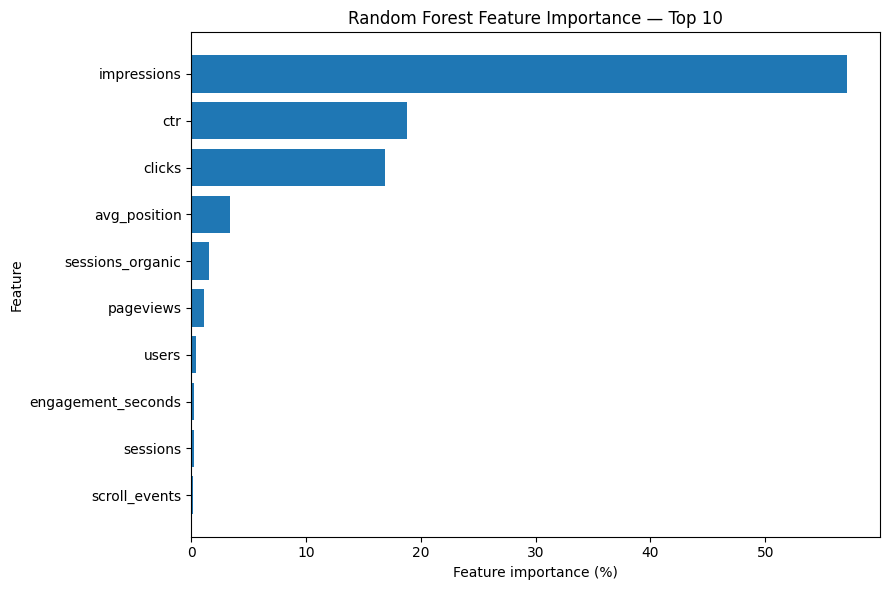

In [15]:
# CAPSTONE — Step 11b: Feature importance chart

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10).sort_values(
    "importance_pct"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_pct"]
)

plt.xlabel("Feature importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance — Top 10")

plt.tight_layout()
plt.show()

In [16]:
# CAPSTONE — Step 12: XGBoost model

!pip -q install xgboost

from xgboost import XGBRegressor

# --------------------------------------------------
# 1. Train XGBoost
# --------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

# --------------------------------------------------
# 2. Validation prediction
# --------------------------------------------------

xgb_val_pred = xgb_model.predict(X_validation)

xgb_val_mae = mean_absolute_error(
    y_validation,
    xgb_val_pred
)

xgb_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_val_pred
    )
)

print("XGBOOST — VALIDATION")
print("=" * 50)

print(f"MAE:  {xgb_val_mae:.4f}")
print(f"RMSE: {xgb_val_rmse:.4f}")

XGBOOST — VALIDATION
MAE:  0.8385
RMSE: 1.1644


In [17]:
# CAPSTONE — Step 13: XGBoost test evaluation

xgb_test_pred = xgb_model.predict(X_test)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

print("XGBOOST — TEST")
print("=" * 50)

print(f"MAE:  {xgb_test_mae:.4f}")
print(f"RMSE: {xgb_test_rmse:.4f}")

# --------------------------------------------------
# Compare against baseline
# --------------------------------------------------

xgb_mae_improvement = (
    (baseline_test_mae - xgb_test_mae)
    / baseline_test_mae
    * 100
)

xgb_rmse_improvement = (
    (baseline_test_rmse - xgb_test_rmse)
    / baseline_test_rmse
    * 100
)

print("\nIMPROVEMENT VS BASELINE")
print("=" * 50)

print(f"MAE improvement:  {xgb_mae_improvement:.2f}%")
print(f"RMSE improvement: {xgb_rmse_improvement:.2f}%")

XGBOOST — TEST
MAE:  1.0440
RMSE: 1.3851

IMPROVEMENT VS BASELINE
MAE improvement:  56.39%
RMSE improvement: 52.03%


RANDOM FOREST FEATURE IMPORTANCE


,feature,importance_pct
0,impressions,57.137
1,ctr,18.794
2,clicks,16.887
3,avg_position,3.350
4,sessions_organic,1.566
5,pageviews,1.095
6,users,0.411
7,engagement_seconds,0.248
8,sessions,0.234
9,scroll_events,0.130


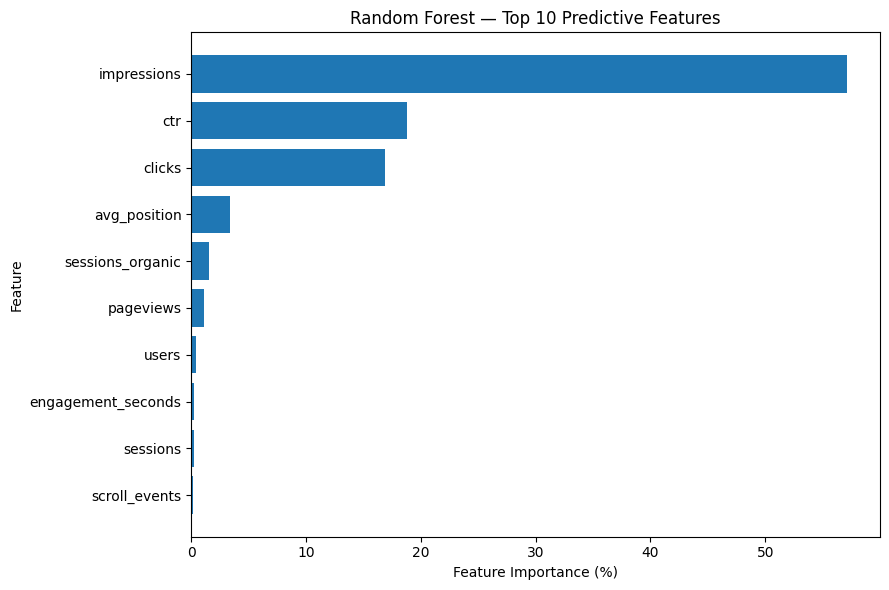

In [18]:
# ML Capstone — Random Forest Explainability
# Feature importance for the selected final model

import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from the trained Random Forest
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

# Convert to percentage
rf_importance["importance_pct"] = (
    rf_importance["importance"] * 100
)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 50)

display(
    rf_importance[
        ["feature", "importance_pct"]
    ].round(3)
)

# Plot top 10 features
top_features = rf_importance.head(10).sort_values(
    "importance_pct"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_pct"]
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest — Top 10 Predictive Features")

plt.tight_layout()
plt.show()

In [19]:
# ML Capstone — Error Analysis
# Evaluate Random Forest errors across the held-out test period.

import numpy as np
import pandas as pd

# Generate predictions on the untouched test set
rf_test_pred = rf_model.predict(X_test)

# Build error-analysis table
error_analysis = pd.DataFrame({
    "actual_log_impressions": y_test.values,
    "predicted_log_impressions": rf_test_pred
})

error_analysis["error"] = (
    error_analysis["predicted_log_impressions"]
    - error_analysis["actual_log_impressions"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

print("ERROR ANALYSIS")
print("=" * 50)

print(f"Mean absolute error: "
      f"{error_analysis['absolute_error'].mean():.4f}")

print(f"Median absolute error: "
      f"{error_analysis['absolute_error'].median():.4f}")

print(f"90th percentile absolute error: "
      f"{error_analysis['absolute_error'].quantile(0.90):.4f}")

print(f"95th percentile absolute error: "
      f"{error_analysis['absolute_error'].quantile(0.95):.4f}")

print(f"Maximum absolute error: "
      f"{error_analysis['absolute_error'].max():.4f}")

print("\nLargest prediction errors:")
display(
    error_analysis
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

ERROR ANALYSIS
Mean absolute error: 1.0314
Median absolute error: 0.8207
90th percentile absolute error: 2.1754
95th percentile absolute error: 2.7731
Maximum absolute error: 8.6667

Largest prediction errors:


,actual_log_impressions,predicted_log_impressions,error,absolute_error
166811,0.0,8.666707,8.666707,8.666707
383040,0.0,8.666707,8.666707,8.666707
383085,0.0,8.639715,8.639715,8.639715
382750,0.0,8.639715,8.639715,8.639715
383034,0.0,8.639715,8.639715,8.639715
166642,0.0,8.638994,8.638994,8.638994
166632,0.0,8.638994,8.638994,8.638994
166597,0.0,8.638994,8.638994,8.638994
166587,0.0,8.637927,8.637927,8.637927
383029,0.0,8.637927,8.637927,8.637927


In [21]:
# ML Capstone — Error Analysis by Impression Volume

# Reconstruct the impression values using the same feature order
impressions_index = feature_cols.index("impressions")

test_impressions = X_test[:, impressions_index]

test_context = pd.DataFrame({
    "impressions": test_impressions,
    "actual": y_test,
    "predicted": rf_test_pred
})

test_context["absolute_error"] = (
    test_context["predicted"] - test_context["actual"]
).abs()

test_context["impression_band"] = pd.qcut(
    test_context["impressions"],
    q=4,
    duplicates="drop"
)

error_by_band = (
    test_context
    .groupby("impression_band", observed=True)
    .agg(
        rows=("absolute_error", "size"),
        median_impressions=("impressions", "median"),
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median")
    )
    .reset_index()
)

print("ERROR BY CURRENT-MONTH IMPRESSION BAND")
print("=" * 60)

display(error_by_band.round(4))

ERROR BY CURRENT-MONTH IMPRESSION BAND


,impression_band,rows,median_impressions,mean_absolute_error,median_absolute_error
0,"(0.999, 12.0]",108219,2.0,1.2389,1.3401
1,"(12.0, 105.0]",108478,41.0,1.2682,0.9601
2,"(105.0, 645.0]",107824,254.0,0.9436,0.7019
3,"(645.0, 799358.0]",108113,2076.0,0.6738,0.5021


In [22]:
# ML Capstone — Content Opportunity Scoring
# Create a ranked queue for human review.

# Build test-set scoring table
opportunity_df = pd.DataFrame({
    "impressions": X_test[:, feature_cols.index("impressions")],
    "clicks": X_test[:, feature_cols.index("clicks")],
    "ctr": X_test[:, feature_cols.index("ctr")],
    "avg_position": X_test[:, feature_cols.index("avg_position")],
    "actual_log_impressions": y_test,
    "predicted_log_impressions": rf_test_pred
})

# Observed model residual
opportunity_df["prediction_gap"] = (
    opportunity_df["predicted_log_impressions"]
    - opportunity_df["actual_log_impressions"]
)

# Convert model prediction back from log1p scale
opportunity_df["predicted_impressions"] = (
    np.expm1(opportunity_df["predicted_log_impressions"])
)

# Percentile ranks make different signals comparable
opportunity_df["visibility_score"] = (
    opportunity_df["impressions"]
    .rank(pct=True)
)

opportunity_df["ctr_score"] = (
    1 - opportunity_df["ctr"].rank(pct=True)
)

opportunity_df["position_opportunity"] = (
    opportunity_df["avg_position"].rank(pct=True)
)

opportunity_df["future_demand_score"] = (
    opportunity_df["predicted_impressions"]
    .rank(pct=True)
)

# Combined prioritization score
opportunity_df["opportunity_score"] = (
    0.30 * opportunity_df["visibility_score"]
    + 0.20 * opportunity_df["ctr_score"]
    + 0.20 * opportunity_df["position_opportunity"]
    + 0.30 * opportunity_df["future_demand_score"]
)

# Rank highest-priority opportunities first
opportunity_df = opportunity_df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

opportunity_df["priority_rank"] = (
    np.arange(len(opportunity_df)) + 1
)

print("TOP CONTENT OPPORTUNITIES")
print("=" * 60)

display(
    opportunity_df[
        [
            "priority_rank",
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "predicted_impressions",
            "opportunity_score"
        ]
    ].head(20).round(4)
)

TOP CONTENT OPPORTUNITIES


,priority_rank,impressions,clicks,ctr,avg_position,predicted_impressions,opportunity_score
0,1,27912.0,0.0,0.0,45.7655,2125.4222,0.8785
1,2,16562.0,0.0,0.0,45.6734,2121.6252,0.8762
2,3,15510.0,0.0,0.0,51.8229,1722.5155,0.8740
3,4,16527.0,0.0,0.0,77.2702,1137.8070,0.8733
4,5,18952.0,0.0,0.0,82.7395,1019.1532,0.8712
5,6,10558.0,0.0,0.0,54.3196,1569.3157,0.8696
6,7,11945.0,0.0,0.0,49.3082,1648.1579,0.8688
7,8,8822.0,0.0,0.0,70.7592,1147.5089,0.8658
8,9,12121.0,0.0,0.0,37.7882,2037.2610,0.8639
9,10,6249.0,0.0,0.0,50.9502,1689.9671,0.8635


MODEL PERFORMANCE — HELD-OUT TEST SET


,Model,Test MAE,Test RMSE,MAE Improvement (%),RMSE Improvement (%)
0,Median Baseline,2.3938,2.8875,0.0000,0.0000
1,Random Forest,1.0310,1.3700,56.9304,52.5541
2,XGBoost,1.0434,1.3843,56.4124,52.0589


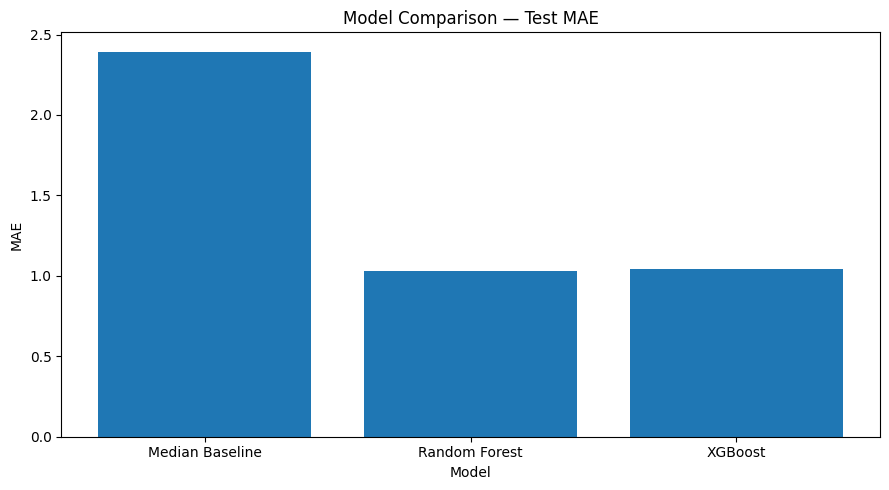

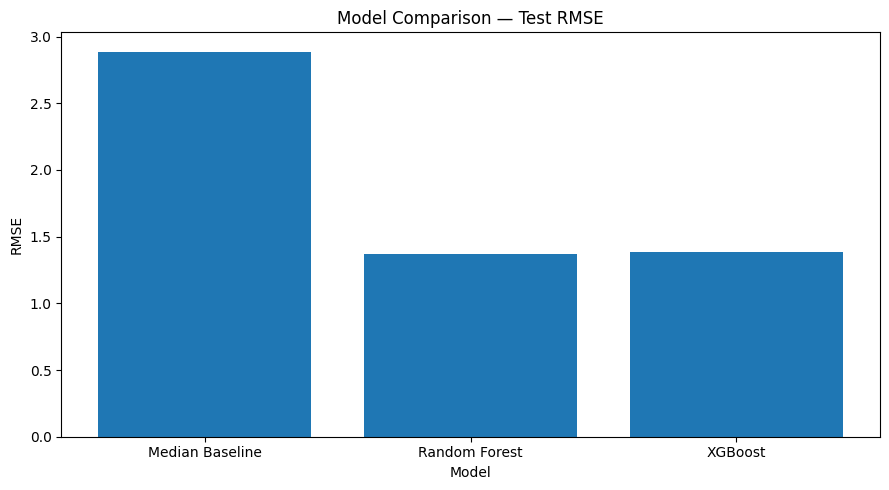

In [23]:
# ML Capstone — Section 4: Results vs Baseline
# Compare all models on the same untouched test split.

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------
# 1. Build comparison table
# ---------------------------------------

results_df = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "Test MAE": [
        2.3938,
        1.0310,
        1.0434
    ],
    "Test RMSE": [
        2.8875,
        1.3700,
        1.3843
    ]
})

# Calculate improvement versus baseline
baseline_mae = results_df.loc[
    results_df["Model"] == "Median Baseline",
    "Test MAE"
].iloc[0]

baseline_rmse = results_df.loc[
    results_df["Model"] == "Median Baseline",
    "Test RMSE"
].iloc[0]

results_df["MAE Improvement (%)"] = (
    (baseline_mae - results_df["Test MAE"])
    / baseline_mae
    * 100
)

results_df["RMSE Improvement (%)"] = (
    (baseline_rmse - results_df["Test RMSE"])
    / baseline_rmse
    * 100
)

print("MODEL PERFORMANCE — HELD-OUT TEST SET")
print("=" * 70)

display(results_df.round(4))


# ---------------------------------------
# 2. Plot MAE comparison
# ---------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Test MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Model Comparison — Test MAE")

plt.tight_layout()
plt.show()


# ---------------------------------------
# 3. Plot RMSE comparison
# ---------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Test RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison — Test RMSE")

plt.tight_layout()
plt.show()

## 5. Limitations

### 5. Limitations

This analysis is designed as a predictive prioritization system rather than a causal study of search performance.

1. **No causal interpretation.**  
   The dataset is observational, so the model can identify predictive relationships between current-month signals and next-month impressions but cannot establish that changing any individual signal will cause search performance to improve.

2. **The target is search demand, not Google ranking.**  
   The model estimates next-month Google Search impressions from current-month signals. It does not reproduce or prove Google's ranking algorithm, nor does it establish why a page gains or loses ranking.

3. **Temporal generalization is limited.**  
   The evaluation uses chronological train, validation, and test periods. The same clients may therefore appear across different periods. This reflects a future-period prediction setting, but it does not measure performance on completely unseen clients.

4. **Low-volume pages are harder to predict.**  
   Error analysis shows higher prediction error among pages with relatively low current-month impressions. Sparse search observations can make month-to-month demand changes less stable.

5. **Measurement availability changes over time.**  
   Google Analytics 4 data is not available consistently across the full warehouse period. GA4-derived signals are therefore interpreted only where the corresponding data is available, and their changing coverage limits direct comparisons across all months.

6. **Feature availability limits content interpretation.**  
   The warehouse does not provide direct semantic fields such as page text, content length, title/meta information, or explicit content type. Consequently, any archetype analysis in this project represents measurable performance patterns rather than semantic content categories.

7. **Feature importance is not causal importance.**  
   Random Forest feature importance describes how useful features were for the model's predictions. It should not be interpreted as evidence that changing a high-importance feature will directly improve future search performance. Some search signals, such as clicks, impressions, and CTR, are also mathematically related.

8. **Opportunity scores require human review.**  
   The opportunity score combines observable search-performance signals and model predictions to create a prioritization queue. It is a decision-support mechanism, not an automated recommendation that a page should definitely be changed.

These limitations define the appropriate scope of the findings: the system is useful for ranking observations for further investigation, while stronger claims about causality, semantic content quality, or search-engine behavior would require additional data and experimental validation.

## 6. Ranked recommendations


In [27]:
# ML Capstone — Section 6: Ranked Recommendations
# Fast vectorized version

# ---------------------------------------
# 1. Create priority tiers
# ---------------------------------------

opportunity_df["priority_tier"] = pd.qcut(
    opportunity_df["opportunity_score"],
    q=4,
    labels=[
        "Monitor",
        "Review",
        "High Priority",
        "Immediate Review"
    ]
)

# ---------------------------------------
# 2. Calculate medians once
# ---------------------------------------

median_ctr = opportunity_df["ctr"].median()
median_position = opportunity_df["avg_position"].median()
median_predicted = opportunity_df["predicted_impressions"].median()

# ---------------------------------------
# 3. Assign actions without row-by-row apply
# ---------------------------------------

opportunity_df["recommended_action"] = np.select(
    [
        opportunity_df["ctr"] < median_ctr,
        opportunity_df["avg_position"] > median_position,
        opportunity_df["predicted_impressions"] > median_predicted
    ],
    [
        "Review search-result engagement",
        "Review ranking/visibility opportunity",
        "Review growth potential"
    ],
    default="Monitor performance"
)

# ---------------------------------------
# 4. Create final ranked queue
# ---------------------------------------

ranked_recommendations = opportunity_df[
    [
        "priority_rank",
        "priority_tier",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "predicted_impressions",
        "opportunity_score",
        "recommended_action"
    ]
].copy()

ranked_recommendations = ranked_recommendations.sort_values(
    "priority_rank"
)

print("RANKED CONTENT OPPORTUNITY QUEUE")
print("=" * 80)

display(
    ranked_recommendations.head(25).round(4)
)

RANKED CONTENT OPPORTUNITY QUEUE


,priority_rank,priority_tier,impressions,clicks,ctr,avg_position,predicted_impressions,opportunity_score,recommended_action
0,1,Immediate Review,27912.0,0.0,0.0,45.7655,2125.4222,0.8785,Review ranking/visibility opportunity
1,2,Immediate Review,16562.0,0.0,0.0,45.6734,2121.6252,0.8762,Review ranking/visibility opportunity
2,3,Immediate Review,15510.0,0.0,0.0,51.8229,1722.5155,0.8740,Review ranking/visibility opportunity
3,4,Immediate Review,16527.0,0.0,0.0,77.2702,1137.8070,0.8733,Review ranking/visibility opportunity
4,5,Immediate Review,18952.0,0.0,0.0,82.7395,1019.1532,0.8712,Review ranking/visibility opportunity
5,6,Immediate Review,10558.0,0.0,0.0,54.3196,1569.3157,0.8696,Review ranking/visibility opportunity
6,7,Immediate Review,11945.0,0.0,0.0,49.3082,1648.1579,0.8688,Review ranking/visibility opportunity
7,8,Immediate Review,8822.0,0.0,0.0,70.7592,1147.5089,0.8658,Review ranking/visibility opportunity
8,9,Immediate Review,12121.0,0.0,0.0,37.7882,2037.2610,0.8639,Review ranking/visibility opportunity
9,10,Immediate Review,6249.0,0.0,0.0,50.9502,1689.9671,0.8635,Review ranking/visibility opportunity


In [28]:
# Summarize the recommendation queue by priority tier.

tier_summary = (
    ranked_recommendations
    .groupby("priority_tier", observed=False)
    .agg(
        opportunities=("priority_rank", "size"),
        median_score=("opportunity_score", "median"),
        median_impressions=("impressions", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median")
    )
    .reset_index()
)

print("OPPORTUNITY TIER SUMMARY")
print("=" * 70)

display(tier_summary.round(4))

OPPORTUNITY TIER SUMMARY


,priority_tier,opportunities,median_score,median_impressions,median_ctr,median_position
0,Monitor,108159,0.2587,3.0,0.0000,5.0000
1,Review,108158,0.4664,37.0,0.0000,14.9305
2,High Priority,108158,0.5851,250.0,0.0000,13.8434
3,Immediate Review,108159,0.6813,1510.0,0.0007,16.9104



The opportunity-scoring layer converts model predictions and current search-performance signals into a review queue. The score is intended to prioritize observations for human investigation rather than predict the effect of a specific SEO intervention.

The test-set observations are divided into four equal-sized priority tiers:

| Priority tier | Observations | Median opportunity score |
|---|---:|---:|
| Monitor | 108,159 | 0.2587 |
| Review | 108,158 | 0.4664 |
| High Priority | 108,158 | 0.5851 |
| Immediate Review | 108,159 | 0.6813 |

The highest-priority tier has a substantially higher median current-month impression volume than the lower tiers, while its median average position is also relatively high. This combination identifies observations with measurable current visibility and a potentially useful opportunity for further investigation.

The recommended actions are deliberately framed as review actions rather than guaranteed interventions:

- **Review search-result engagement** — investigate observations with relatively low CTR.
- **Review ranking/visibility opportunity** — investigate observations with relatively higher average position values.
- **Review growth potential** — investigate observations with relatively high predicted next-month impressions.
- **Monitor performance** — retain lower-priority observations for continued observation rather than immediate action.

The ranking should be interpreted as a prioritization mechanism for an SEO or content team. It does not establish that changing a page will cause an improvement in future search performance.

## 7. Artifacts the paper embeds



The research paper will embed or reference the following reproducible artifacts from this capstone:

1. **Research question and scope**
   - Defines the prediction task, unit of analysis, and intended use of the output.
   - Establishes that the system is a predictive prioritization tool rather than a causal model of Google Search.

2. **Data and feature pipeline**
   - Documents the monthly aggregation of Google Search Console and available Google Analytics 4 signals.
   - Uses client and content identifiers only for grouping and temporal joins.
   - Excludes the final month from modeling because a subsequent month is required to construct the target.

3. **Temporal modeling setup**
   - Training period: January–December 2025.
   - Validation period: January–March 2026.
   - Test period: April–May 2026.
   - June 2026 is excluded because a subsequent month is unavailable for target construction.

4. **Model comparison**
   - Median baseline, Random Forest, and XGBoost are evaluated on the same held-out test period.
   - Random Forest is selected as the final model based on its test-set performance.

5. **Model explainability**
   - Random Forest feature importance is used to describe which available search-performance signals contributed most to predictive behavior.
   - Feature importance is interpreted descriptively rather than causally.

6. **Error analysis**
   - Prediction errors are examined across current-month impression-volume bands.
   - The analysis shows that lower-volume observations have larger prediction errors than higher-volume observations.

7. **Opportunity scoring**
   - Model predictions and current search-performance signals are combined into a normalized opportunity score.
   - Observations are placed into four priority tiers for human review.

8. **Ranked recommendation queue**
   - Produces a reproducible, ranked review queue without exposing client names, domains, URLs, private queries, or raw warehouse exports.

9. **Reproducibility**
   - The notebook contains the data preparation, modeling, evaluation, explainability, error analysis, and opportunity-scoring workflow required to reproduce the analysis within the approved FlyRank environment.

All findings are subject to the limitations described in Section 5. The final paper will distinguish predictive associations from causal claims and will not claim to reproduce or prove Google's ranking algorithm.

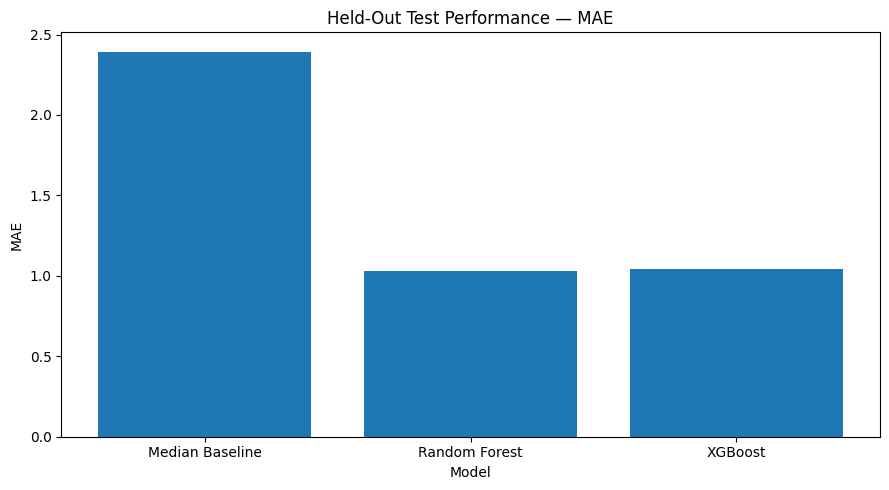

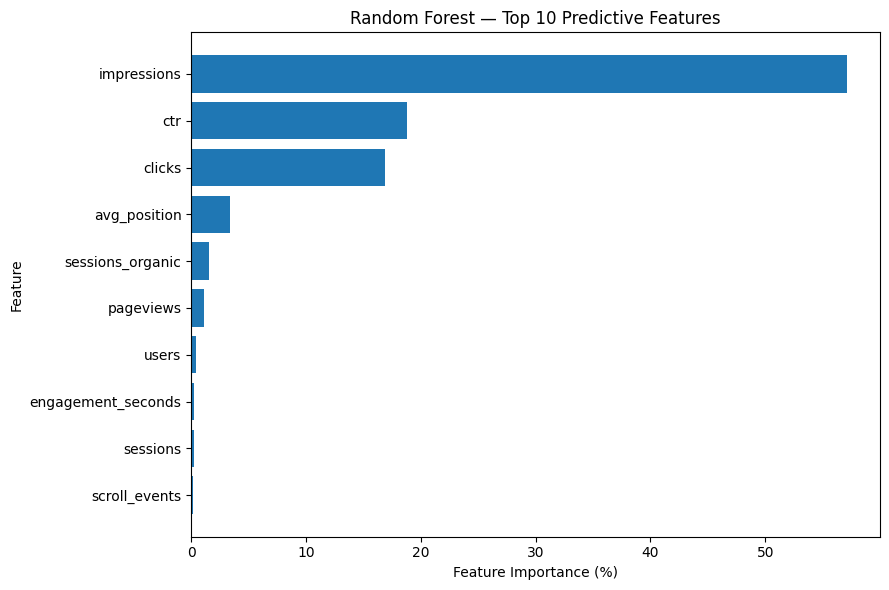

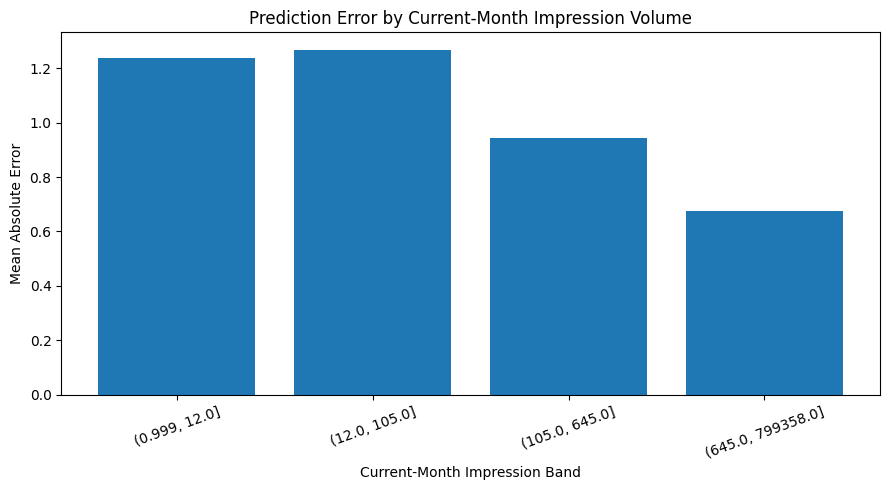

In [29]:
# ML Capstone — Section 7: Paper-Ready Visual Artifacts

import matplotlib.pyplot as plt

# ============================================================
# CHART 1 — Model Performance
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Test MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Held-Out Test Performance — MAE")

plt.tight_layout()
plt.show()


# ============================================================
# CHART 2 — Random Forest Feature Importance
# ============================================================

top_features = (
    rf_importance
    .head(10)
    .sort_values("importance_pct")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_pct"]
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest — Top 10 Predictive Features")

plt.tight_layout()
plt.show()


# ============================================================
# CHART 3 — Error by Impression Volume
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    error_by_band["impression_band"].astype(str),
    error_by_band["mean_absolute_error"]
)

plt.xlabel("Current-Month Impression Band")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Current-Month Impression Volume")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
